In [1]:
import pandas as pd
import numpy as np

In [2]:
# Custom functions
from core.demand_calculations import *

# Energy

## Capacity technology data

In [3]:
cap_tech_df = pd.read_excel(r'data/data.xlsx', sheet_name='ELEC_CAP_TECH')
mi_df = pd.read_excel(r'data/data.xlsx', sheet_name='MI')

In [4]:
cap_tech_can_df = cap_tech_df[cap_tech_df['Region'] == 'Canada']
cap_tech_can_df

,Scenario,Region,Variable,Year,Value,Unit
775,Canada Net-zero,Canada,Battery Storage,2020,95.0,MW
776,Canada Net-zero,Canada,Battery Storage,2021,95.0,MW
777,Canada Net-zero,Canada,Battery Storage,2022,140.0,MW
778,Canada Net-zero,Canada,Battery Storage,2023,140.0,MW
779,Canada Net-zero,Canada,Battery Storage,2024,140.0,MW
...,...,...,...,...,...,...
9481,Global Net-zero,Canada,Uranium SMR,2046,22671.0,MW
9482,Global Net-zero,Canada,Uranium SMR,2047,22996.0,MW
9483,Global Net-zero,Canada,Uranium SMR,2048,23311.0,MW
9484,Global Net-zero,Canada,Uranium SMR,2049,23627.0,MW


In [5]:
# Create a df with the unique variable names
variables_df = pd.DataFrame(cap_tech_can_df['Variable'].unique(), columns=['Variable'])
variables_df

,Variable
0,Battery Storage
1,Bioenergy
2,Bioenergy with CCUS
3,Coal and Coke
4,Coal with CCUS
5,Hydro
6,Hydrogen
7,Natural Gas
8,Natural Gas with CCUS
9,Offshore Wind


In [6]:
# Remove Battery Storage and Total in the cap_tech_can_df
cap_tech_can_df = cap_tech_can_df[
    (cap_tech_can_df['Variable'] != 'Battery Storage') &
    (cap_tech_can_df['Variable'] != 'Total')
]

## Define mapping dictionnary between CER technologies and MI sub-technologies

In [7]:
nrj_mi_mapping = {
    "Bioenergy": [("Biomass, Aggregated", 1.0)],
    "Bioenergy with CCUS": [("Biomass, Aggregated", 1.0)],
    "Coal and coke": [("Fossil energy, Coal", 1.0)],
    "Coal with CCUS": [("Fossil energy, Coal", 1.0)],
    "Hydro": [("Hydroelectricity, Aggregated", 1.0)],
    "Hydrogen": [("Fossil energy, Hydrogen", 1.0)],
    "Natural Gas": [("Fossil energy, Natural gas", 1.0)],
    "Natural Gas with CCUS": [("Fossil energy, Natural gas", 1.0)],
    "Onshore Wind": [("Wind, Onshore", 1.0)],
    "Offshore Wind": [("Wind, Offshore", 1.0)],
    "Oil": [("Fossil energy, Natural gas", 1.0)],
    "Solar (Distributed)": [("Solar PV, Aggregated", 1.0)],
    "Solar (Utility scale)": [("Solar CSP, Aggregated", 1.0)],
    "Uranium": [("Nuclear, Nuclear Aggregated", 1.0)],
    "Uranium SMR": [("Nuclear, Nuclear Boiling water power plant", 0.8), ("Nuclear, HTGR", 0.2)],
}

## Disaggregate capacity data based on the mapping dictionary

In [12]:
cap_tech_can_disagg_df = disaggregate_capacity(cap_tech_can_df, nrj_mi_mapping, tech_col="Variable", cap_col="Value")

In [13]:
cap_tech_can_disagg_df

,Scenario,Region,Variable,Year,Value,Unit,Associated_MI
806,Canada Net-zero,Canada,Bioenergy,2020,2524.1,MW,"Biomass, Aggregated"
807,Canada Net-zero,Canada,Bioenergy,2021,2543.1,MW,"Biomass, Aggregated"
808,Canada Net-zero,Canada,Bioenergy,2022,2543.1,MW,"Biomass, Aggregated"
809,Canada Net-zero,Canada,Bioenergy,2023,2543.1,MW,"Biomass, Aggregated"
810,Canada Net-zero,Canada,Bioenergy,2024,2543.1,MW,"Biomass, Aggregated"
...,...,...,...,...,...,...,...
9483,Global Net-zero,Canada,Uranium SMR,2048,4662.2,MW,"Nuclear, HTGR"
9484,Global Net-zero,Canada,Uranium SMR,2049,18901.6,MW,"Nuclear, Nuclear Boiling water power plant"
9484,Global Net-zero,Canada,Uranium SMR,2049,4725.4,MW,"Nuclear, HTGR"
9485,Global Net-zero,Canada,Uranium SMR,2050,19183.2,MW,"Nuclear, Nuclear Boiling water power plant"


In [14]:
# Put the value in GW and
cap_tech_can_disagg_df['Value'] = cap_tech_can_disagg_df['Value'] / 1000
cap_tech_can_disagg_df['Unit'] = 'GW'

In [15]:
cap_tech_can_disagg_df

,Scenario,Region,Variable,Year,Value,Unit,Associated_MI
806,Canada Net-zero,Canada,Bioenergy,2020,2.5241,GW,"Biomass, Aggregated"
807,Canada Net-zero,Canada,Bioenergy,2021,2.5431,GW,"Biomass, Aggregated"
808,Canada Net-zero,Canada,Bioenergy,2022,2.5431,GW,"Biomass, Aggregated"
809,Canada Net-zero,Canada,Bioenergy,2023,2.5431,GW,"Biomass, Aggregated"
810,Canada Net-zero,Canada,Bioenergy,2024,2.5431,GW,"Biomass, Aggregated"
...,...,...,...,...,...,...,...
9483,Global Net-zero,Canada,Uranium SMR,2048,4.6622,GW,"Nuclear, HTGR"
9484,Global Net-zero,Canada,Uranium SMR,2049,18.9016,GW,"Nuclear, Nuclear Boiling water power plant"
9484,Global Net-zero,Canada,Uranium SMR,2049,4.7254,GW,"Nuclear, HTGR"
9485,Global Net-zero,Canada,Uranium SMR,2050,19.1832,GW,"Nuclear, Nuclear Boiling water power plant"


In [16]:
mi_df

,Technology,Sub-technology,Metal,Metal intensity,Unit,Reference,Fiability of the data,Comment
0,Biomass,Aggregated,Aluminum,3900.0,t/GW,"(Ashby, 2013)",Small variability in data,NaN
1,Biomass,Aggregated,Aluminum,1300.0,t/GW,"(Sullivan et al., 2010)",Small variability in data,NaN
2,Biomass,Aggregated,Aluminum,271.2,t/GW,"(Van Oorschot et al., 2022), (Bauer 2007, Moss...",Variability in data,NaN
3,Biomass,Wood energy,Aluminum,184.0,t/GW,Open LCA Analysis 'Wood energy',Important variability in data,NaN
4,Biomass,Aggregated,Chromium,2.0,t/GW,"(Ashby, 2013)",Variability in data,NaN
...,...,...,...,...,...,...,...,...
675,Wind,GB-PMSG,Zinc,5500.0,t/GW,"(European Commission, 2020)",Small variability in data,Hybride
676,Wind,Offshore,Zinc,5500.0,t/GW,"(IEA, 2022)",Small variability in data,NaN
677,Wind,Offshore,Zinc,5450.0,t/GW,(Watari et al. 2019),Small variability in data,NaN
678,Wind,Onshore,Zinc,5500.0,t/GW,"(IEA, 2022)",Small variability in data,NaN


In [31]:
mi_df.to_csv(r'mi_df.csv', index=False)

In [17]:
metal_demand_nrj = calculate_metal_demand(cap_tech_can_disagg_df, mi_df)

In [18]:
metal_demand_nrj_nz = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Canada Net-zero']
metal_demand_nrj_step = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Canada Current Measures']

In [19]:
metal_demand_nrj_nz

,Scenario,Region,Year,Variable,Metal,Metal intensity (t/GW),Metal_demand_t,Fiability_used,Comment
0,Canada Net-zero,Canada,2020,Bioenergy,Aluminum,2600.0,6562.66000,Small variability in data,mean of Small variability in data
1,Canada Net-zero,Canada,2020,Bioenergy,Chromium,2.0,5.04820,Variability in data,None
2,Canada Net-zero,Canada,2020,Bioenergy,Cobalt,2.0,5.04820,Variability in data,None
3,Canada Net-zero,Canada,2020,Bioenergy,Concrete,159000.0,401331.90000,No comparison,None
4,Canada Net-zero,Canada,2020,Bioenergy,Copper,2222.5,5609.81225,Small variability in data,mean of Small variability in data
...,...,...,...,...,...,...,...,...,...
3963,Canada Net-zero,Canada,2050,Uranium SMR,NaN,NaN,NaN,NaN,NaN
3964,Canada Net-zero,Canada,2050,Uranium SMR,Copper,24.8,125.47312,Small variability in data,None
3965,Canada Net-zero,Canada,2050,Uranium SMR,Molybdenum,18.3,92.58702,Variability in data,None
3966,Canada Net-zero,Canada,2050,Uranium SMR,Nickel,33.7,170.50178,Variability in data,None


In [20]:
metal_demand_nrj_nz

,Scenario,Region,Year,Variable,Metal,Metal intensity (t/GW),Metal_demand_t,Fiability_used,Comment
0,Canada Net-zero,Canada,2020,Bioenergy,Aluminum,2600.0,6562.66000,Small variability in data,mean of Small variability in data
1,Canada Net-zero,Canada,2020,Bioenergy,Chromium,2.0,5.04820,Variability in data,None
2,Canada Net-zero,Canada,2020,Bioenergy,Cobalt,2.0,5.04820,Variability in data,None
3,Canada Net-zero,Canada,2020,Bioenergy,Concrete,159000.0,401331.90000,No comparison,None
4,Canada Net-zero,Canada,2020,Bioenergy,Copper,2222.5,5609.81225,Small variability in data,mean of Small variability in data
...,...,...,...,...,...,...,...,...,...
3963,Canada Net-zero,Canada,2050,Uranium SMR,NaN,NaN,NaN,NaN,NaN
3964,Canada Net-zero,Canada,2050,Uranium SMR,Copper,24.8,125.47312,Small variability in data,None
3965,Canada Net-zero,Canada,2050,Uranium SMR,Molybdenum,18.3,92.58702,Variability in data,None
3966,Canada Net-zero,Canada,2050,Uranium SMR,Nickel,33.7,170.50178,Variability in data,None


In [22]:
metal_demand_nrj_nz.to_csv(r'metal_demand_nrj_nz.csv', index=False)

In [ ]:
# Idea for graphs
## Subplots per metals (Penelope style) 2020-2050
## Aggregated per technology 2020-2050
## Aggregated per metal 2020-2050

In [100]:
df = metal_demand_nrj_nz

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Load data ---
#df = pd.read_csv("metal_demand_nrj_nz.csv")

# --- Clean & prepare ---
#df = df.copy()
df["Year"] = df["Year"].astype(int)
df = df.sort_values(["Metal", "Year", "Variable"])

# === COLOR DICTIONARIES ===
# You can customize these later (hex codes)
metal_colors = {
    "Aluminum":      "#e66101",
    "Boron":         "#fdb863",
    "Chromium":      "#b2abd2",
    "Cobalt":        "#5e3c99",
    "Concrete":      "#999999",
    "Copper":        "#d95f02",
    "Dysprosium":    "#2166ac",
    "Gallium":       "#92c5de",
    "Glass":         "#bababa",
    "Iron":          "#7f3b08",
    "Lead":          "#542788",
    "Magnesium":     "#a6dba0",
    "Manganese":     "#de77ae",
    "Molybdenum":    "#8c510a",
    "Neodymium":     "#762a83",
    "Nickel":        "#1b7837",
    "Niobium":       "#80cdc1",
    "Polymers":      "#dfc27d",
    "Praesodymium":  "#af8dc3",
    "REE":           "#bf812d",
    "Silicium":      "#c2a5cf",
    "Silver":        "#cccccc",
    "Terbium":       "#35978f",
    "Vanadium":      "#9970ab",
    "Zinc":          "#f4a582",
    "Other":         "#999999"
}

tech_colors = {
    "Hydro": "#f6e8c3",
    "Solar (Distributed)": "#8c510a",
    "Solar (Utility scale)": "#d8b365",
    "Offshore Wind": "#c7eae5",
    "Onshore Wind": "#5ab4ac",
    "Bioenergy": "#01665e",
    "Bioenergy with CCUS": "#003c30",
    "Natural Gas": "#dfc27d",
    "Natural Gas with CCUS": "#a6611a",
    "Coal": "#878787",
    "Coal with CCUS": "#4d4d4d",
    "Hydrogen": "#80cdc1",
    "Oil": "#b8b8b8",
    "Uranium": "#fee08b",
    "Uranium SMR": "#d73027",
    "Other": "#999999"
}



C:\Users\mp_ma\AppData\Local\Temp\ipykernel_1996\2740081015.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Year"].astype(int)


In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch



def plot_metal_demand_facets(
    df,
    tech_colors,
    threshold=0.01,   # group techs < 1% within each metal into "Other"
    ncols=6,
    figsize=(14, 10),
    dpi=350,
    savepath=None,
    add_total_line=False,
):
    """
    Compact grid of stacked-bar subplots.
    One subplot per Metal, stacked by Variable (technology).
    Shows decade ticks only. Single global legend outside.
    """
    import matplotlib.ticker as mticker

    # --- Clean & guard ---
    d0 = df.copy()
    d0 = d0[d0["Metal"].notna() & d0["Variable"].notna()]
    d0["Metal"] = d0["Metal"].astype(str).str.strip()
    d0["Variable"] = d0["Variable"].astype(str).str.strip()
    d0["Year"] = d0["Year"].astype(int)

    metals = sorted(d0["Metal"].unique().tolist())
    n_metals = len(metals)
    nrows = int(np.ceil(n_metals / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, dpi=dpi, sharex=False, sharey=False
    )
    axes = axes.flatten()

    # We'll collect legend entries actually present after thresholding
    legend_labels = set()

    for i, metal in enumerate(metals):
        ax = axes[i]

        d_m = d0[d0["Metal"] == metal]

        # Group small technologies within THIS metal
        totals = d_m.groupby("Variable")["Metal_demand_t"].sum().sort_values(ascending=False)
        share = totals / totals.sum() if totals.sum() != 0 else totals*0
        small = share[share < threshold].index.tolist()
        d_m = d_m.copy()
        if len(small) > 0:
            d_m.loc[d_m["Variable"].isin(small), "Variable"] = "Other"

        # Pivot for stacked bars
        pivot = d_m.pivot_table(index="Year", columns="Variable",
                                values="Metal_demand_t", aggfunc="sum", fill_value=0)
        pivot = pivot.sort_index()  # ensure years increasing

        # If nothing to plot (all zeros), create empty axes
        if pivot.sum().sum() == 0:
            ax.set_title(metal, fontsize=8, pad=1)
            ax.set_xticks([2020, 2030, 2040, 2050])
            ax.set_xticklabels(["2020", "2030", "2040", "2050"], fontsize=7)
            ax.tick_params(axis="y", labelsize=7)
            ax.grid(False)
            continue

        # Determine colors for the columns; "Other" grey
        cols = pivot.columns.tolist()
        bar_colors = [("#999999" if c == "Other" else tech_colors.get(c, "#cccccc")) for c in cols]

        # Plot stacked bars (suppress per-axes legend)
        pivot.plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.9, legend=False)

        # Collect legend labels that appear
        legend_labels.update(cols)

        # Ticks: decade only (ensure tick positions align to bars)
        ax.tick_params(axis="x", labelrotation=0, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        # format y
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M" if x >= 1e6 else (f"{x/1e3:.0f}k" if x>=1e3 else f"{int(x)}"))
        )

        # Set decade labels only
        years = pivot.index.tolist()
        tick_positions = np.arange(len(years))
        tick_labels = [str(y) if (y % 10 == 0) else "" for y in years]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=7)

        ax.set_title(metal, fontsize=8, pad=1)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if add_total_line:
            totals_by_year = pivot.sum(axis=1).values
            ax.plot(tick_positions, totals_by_year, linewidth=1.2)

    # Remove any unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Build a single global legend from labels actually used
    labels_sorted = sorted(list(legend_labels), key=lambda x: (x != "Other", x))
    handles = []
    for lab in labels_sorted:
        color = "#999999" if lab == "Other" else tech_colors.get(lab, "#cccccc")
        handles.append(Patch(facecolor=color, edgecolor="none", label=lab))

    if handles:
        fig.legend(
            handles=handles,
            labels=[h.get_label() for h in handles],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.01),
            ncol=min(len(handles), 8),
            fontsize=8,
            frameon=False,
        )

    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    fig.subplots_adjust(hspace=0.5, wspace=0.2, bottom=0.14)

    if savepath:
        fig.savefig(f"{savepath}.png", bbox_inches="tight")
        fig.savefig(f"{savepath}.svg", bbox_inches="tight")

    plt.show()

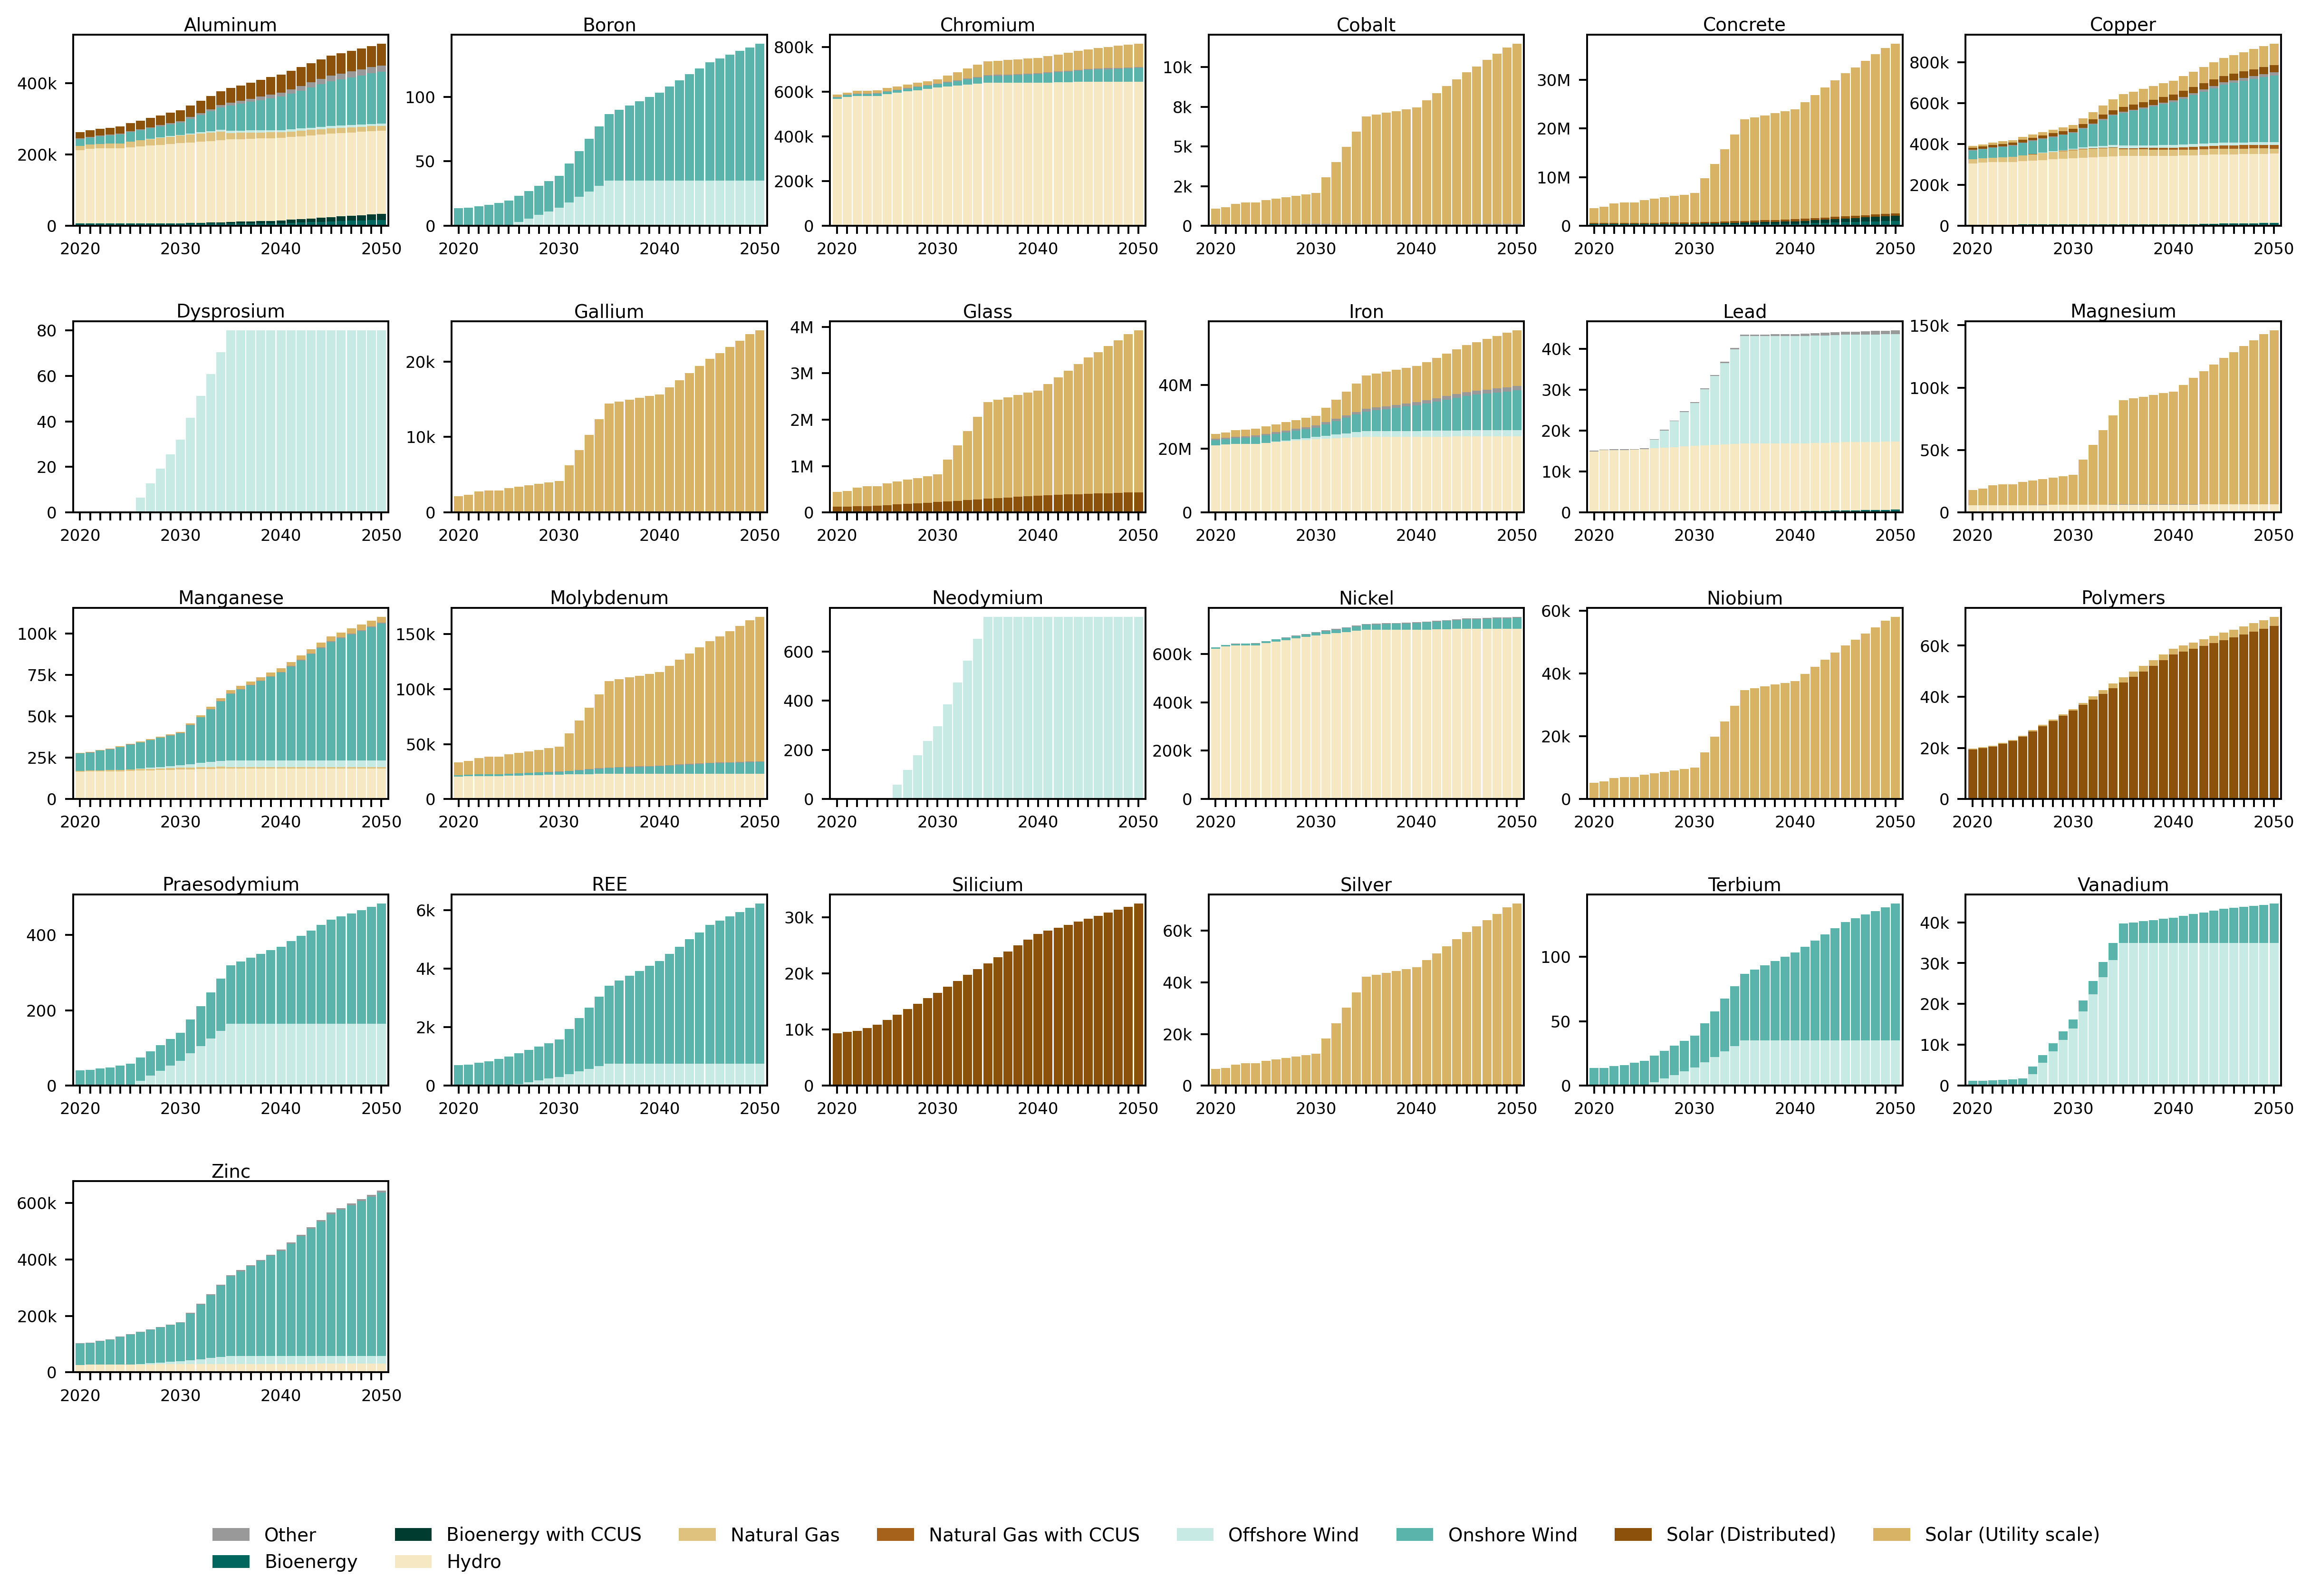

In [103]:
plot_metal_demand_facets(df, tech_colors, savepath=r'results/metal_demand_nrj_facets')

In [104]:
def plot_metal_demand_stackplots(
    df,
    metal_colors,
    tech_colors,
    figsize=(8, 12),
    dpi=350,
    ncol_legend=4,
    threshold=0.01,  # percentage threshold (e.g. 0.01 = 1%)
    savepath=None,
):
    """
    Plot two stacked area charts:
    (1) total metal demand by technology (Variable)
    (2) total metal demand by metal (Metal)
    Small categories (< threshold of total) are grouped as 'Other'.
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # ---- Helper to group small contributors ----
    def group_small_categories(df_pivot, threshold):
        total_all = df_pivot.sum(axis=1).sum()
        total_per_cat = df_pivot.sum()
        share = total_per_cat / total_all
        small_cats = share[share < threshold].index

        if len(small_cats) > 0:
            df_grouped = df_pivot.copy()
            df_grouped["Other"] = df_pivot[small_cats].sum(axis=1)
            df_grouped = df_grouped.drop(columns=small_cats)
        else:
            df_grouped = df_pivot
        return df_grouped

    # ---- Prepare data ----
    data_var = df.pivot_table(
        index="Year", columns="Variable", values="Metal_demand_t",
        aggfunc="sum", fill_value=0
    )
    data_met = df.pivot_table(
        index="Year", columns="Metal", values="Metal_demand_t",
        aggfunc="sum", fill_value=0
    )

    # ---- Apply grouping ----
    data_var = group_small_categories(data_var, threshold)
    data_met = group_small_categories(data_met, threshold)

    # ---- Figure ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, dpi=dpi, sharex=True)

    # ---- 1️⃣ By Variable ----
    colors_var = [tech_colors.get(v, "#cccccc") for v in data_var.columns]
    if "Other" in data_var.columns:
        colors_var[data_var.columns.get_loc("Other")] = "#999999"

    ax1.stackplot(data_var.index, data_var.T, labels=data_var.columns, colors=colors_var)
    ax1.set_title("Total metal demand by technology", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Metal demand (t)")

    ax1.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol_legend,
        frameon=False,
        fontsize=10,
    )

    # ---- 2️⃣ By Metal ----
    colors_met = [metal_colors.get(m, "#cccccc") for m in data_met.columns]
    if "Other" in data_met.columns:
        colors_met[data_met.columns.get_loc("Other")] = "#999999"

    ax2.stackplot(data_met.index, data_met.T, labels=data_met.columns, colors=colors_met)
    ax2.set_title("Total metal demand by metal", fontsize=12, fontweight="bold")
    #ax2.set_xlabel("Year")
    ax2.set_ylabel("Metal demand (t)")

    ax2.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol_legend,
        frameon=False,
        fontsize=10,
    )

    # ---- Layout ----
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.subplots_adjust(hspace=0.5)

    # ---- Save ----
    if savepath:
        fig.savefig(f"{savepath}.png", bbox_inches="tight")
        fig.savefig(f"{savepath}.svg", bbox_inches="tight")
        print(f"✅ Figure saved to {savepath}.png and .svg")

    plt.show()


✅ Figure saved to results/metal_demand_nrj_stackplots.png and .svg


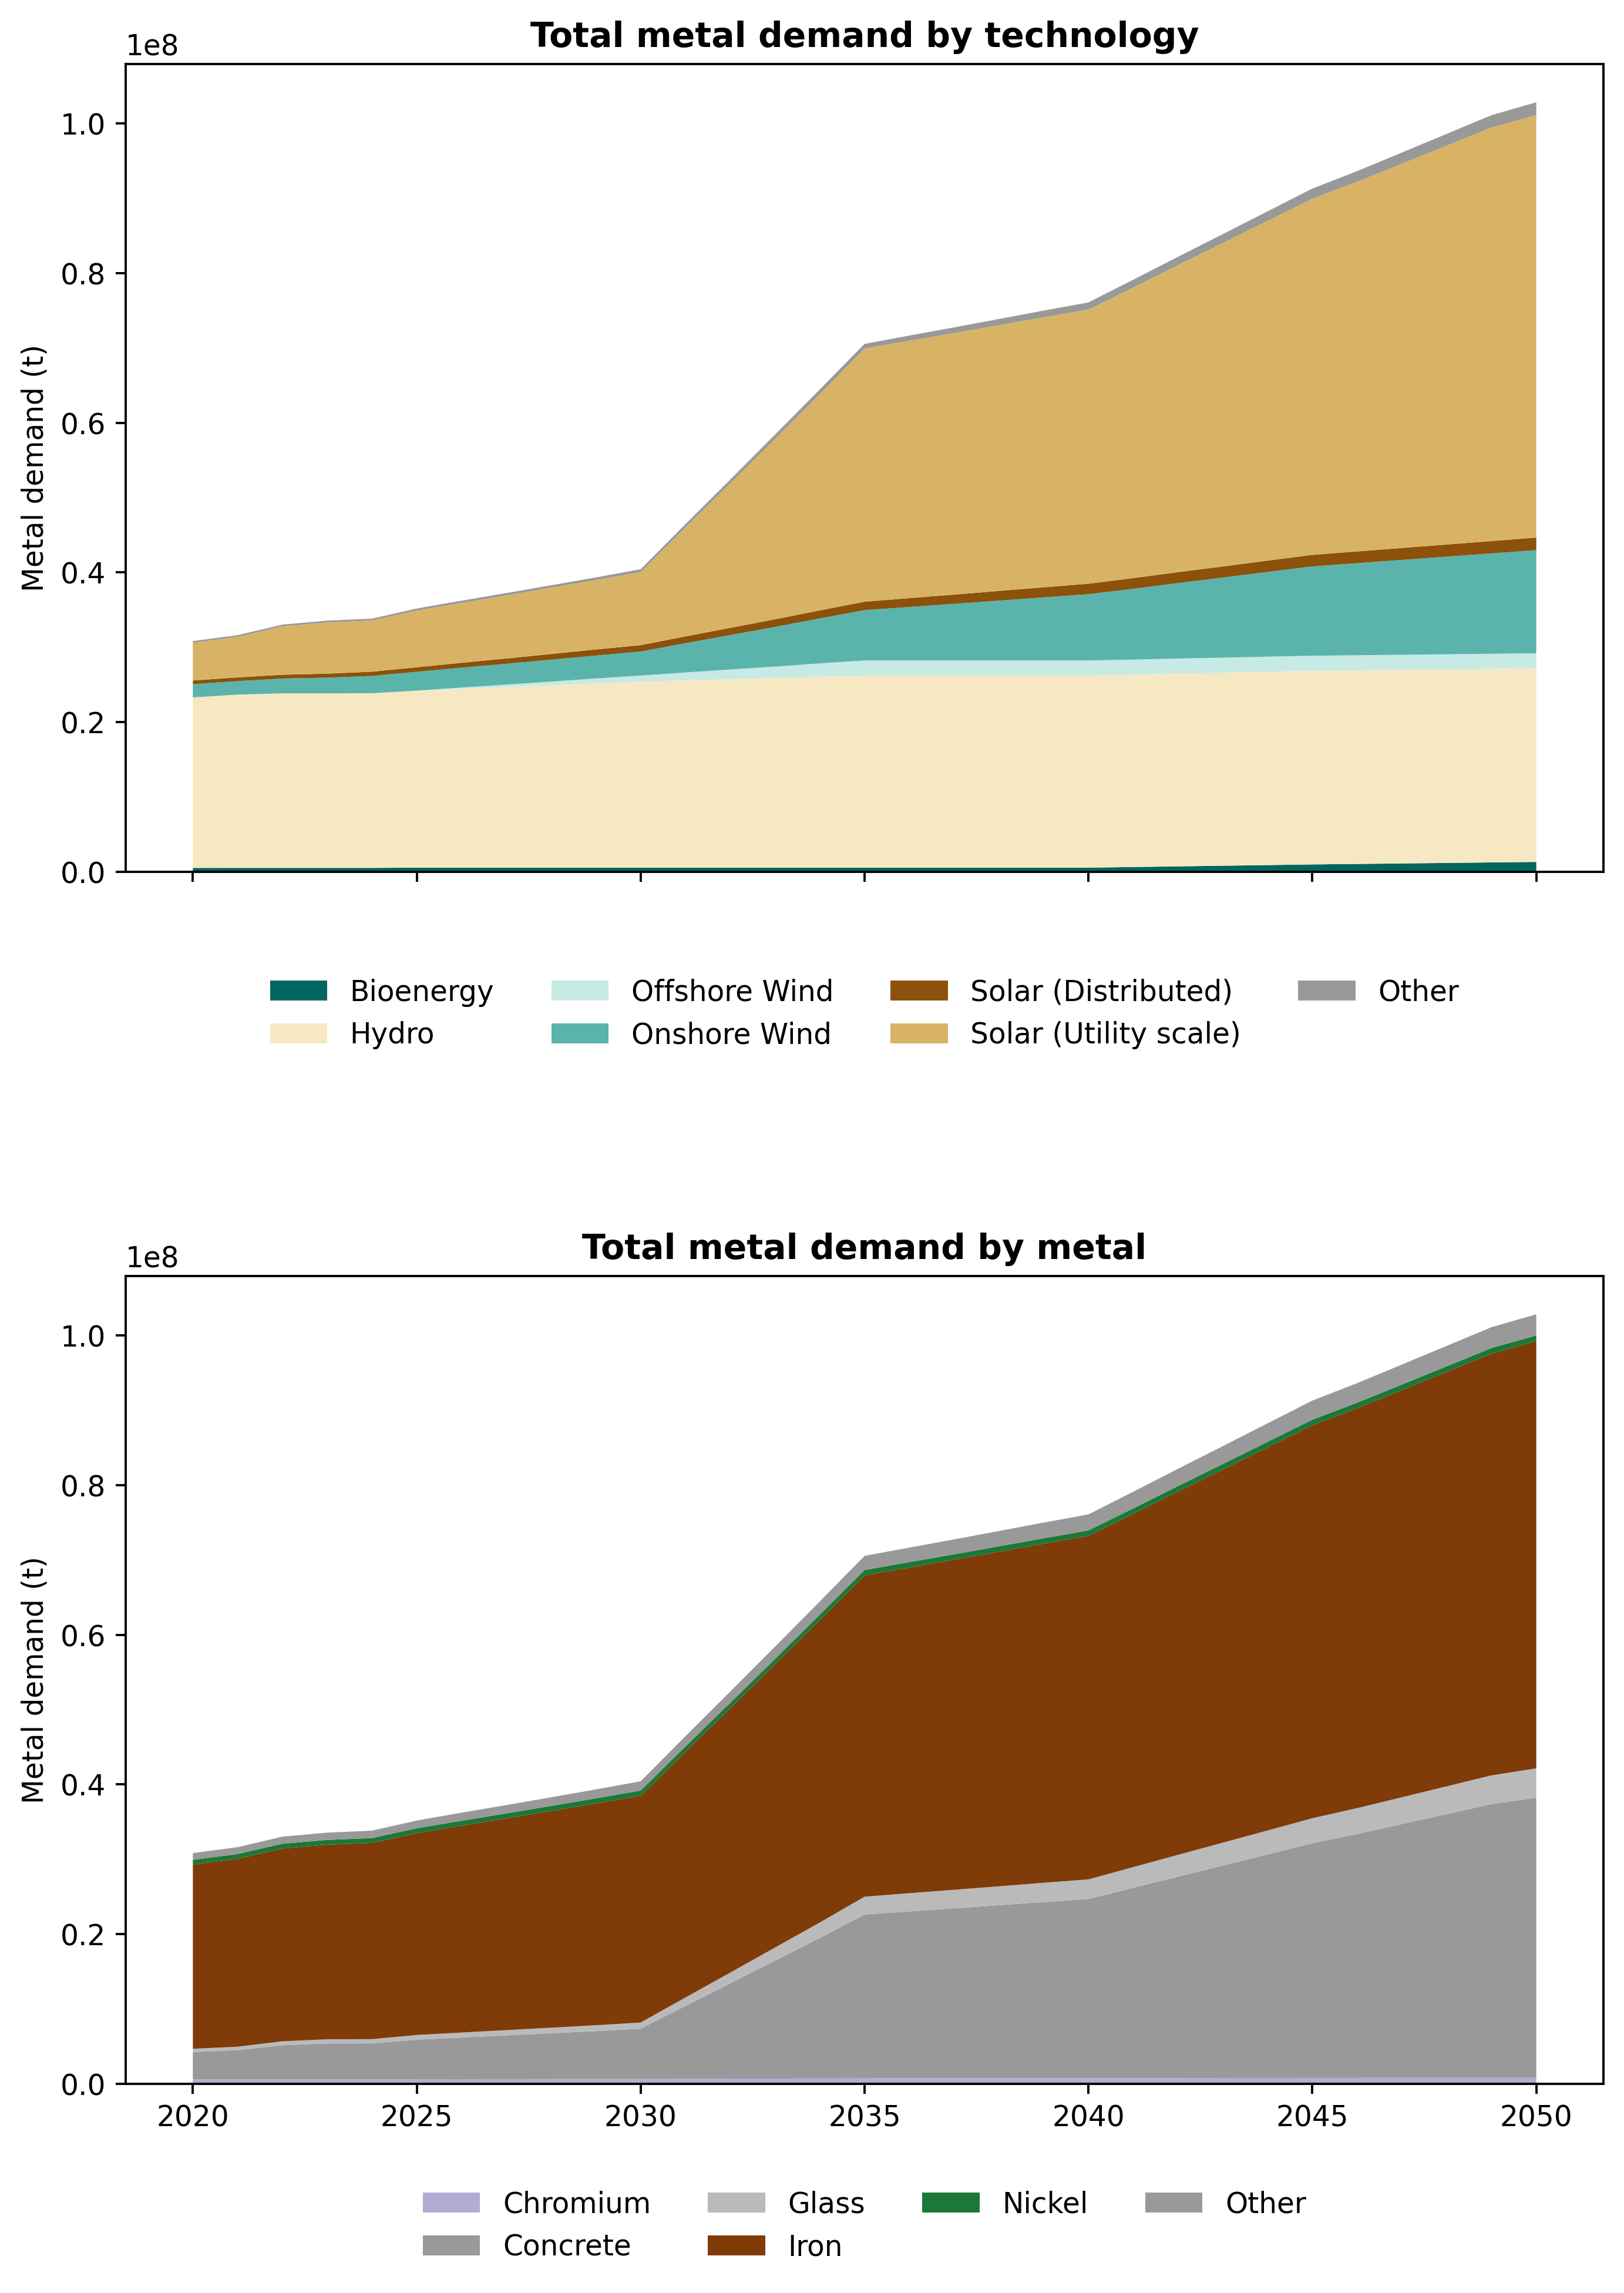

In [105]:
plot_metal_demand_stackplots(df, metal_colors, tech_colors, savepath=r'results/metal_demand_nrj_stackplots')

# EVs

## Import data

In [50]:
# EV sales data in Canada from IEA
ev_df = pd.read_excel(r'data/data.xlsx', sheet_name='EVs_CAN')

In [51]:
ev_df = ev_df[
    (ev_df['Parameter'] == 'EV sales') &
    (ev_df['Year'] == 2024)
]

In [52]:
ev_df

,Country,Parameter,Mode,Powertrain,Year,Unit,Value
3,Canada,EV sales,2 and 3 wheelers,BEV,2024,Vehicles,170.0
22,Canada,EV sales,Buses,BEV,2024,Vehicles,210.0
29,Canada,EV sales,Cars,BEV,2024,Vehicles,190000.0
48,Canada,EV sales,Trucks,BEV,2024,Vehicles,2000.0
51,Canada,EV sales,Vans,BEV,2024,Vehicles,11000.0
66,Canada,EV sales,Buses,FCEV,2024,Vehicles,13.0
101,Canada,EV sales,Cars,FCEV,2024,Vehicles,20.0
105,Canada,EV sales,Trucks,FCEV,2024,Vehicles,6.0
123,Canada,EV sales,Cars,PHEV,2024,Vehicles,62000.0
130,Canada,EV sales,Vans,PHEV,2024,Vehicles,6400.0


In [54]:
# End use demand for transport sector in PJ from CER scenarios
transport_demand_ef = pd.read_excel(r'data/data.xlsx', sheet_name='END_USE_TRANSPORT')

In [55]:
# Filter for Year 2024 and above, variable = electricity and region = Canada
transport_demand_elec_ef = transport_demand_ef[
    (transport_demand_ef['Region'] == 'Canada') &
    (transport_demand_ef['Year'] >= 2024) &
    (transport_demand_ef['Variable'] == 'Electricity')
]

In [56]:
transport_demand_elec_ef

,Scenario,Region,Variable,Year,Value,Sector,Unit
1224,Current Measures,Canada,Electricity,2024,11.5558,Transportation,PJ
1235,Current Measures,Canada,Electricity,2025,16.5362,Transportation,PJ
1246,Current Measures,Canada,Electricity,2026,22.2906,Transportation,PJ
1257,Current Measures,Canada,Electricity,2027,28.3160,Transportation,PJ
1268,Current Measures,Canada,Electricity,2028,34.8046,Transportation,PJ
...,...,...,...,...,...,...,...
18336,Global Net-zero,Canada,Electricity,2046,687.7432,Transportation,PJ
18477,Global Net-zero,Canada,Electricity,2047,709.8365,Transportation,PJ
18618,Global Net-zero,Canada,Electricity,2048,731.0948,Transportation,PJ
18759,Global Net-zero,Canada,Electricity,2049,751.4916,Transportation,PJ


## Compute future EV sales based on growth factors (based on 2024 values)

In [58]:
ev_growth_df = compute_ev_growth(transport_demand_elec_ef)

In [59]:
ev_growth_df

,Scenario,Year,Growth_Factor
1224,Current Measures,2024,1.000000
1235,Current Measures,2025,1.430987
1246,Current Measures,2026,1.928953
1257,Current Measures,2027,2.450371
1268,Current Measures,2028,3.011873
...,...,...,...
18336,Global Net-zero,2046,40.554722
18477,Global Net-zero,2047,41.857516
18618,Global Net-zero,2048,43.111072
18759,Global Net-zero,2049,44.313827


In [61]:
# Apply the function
projected_ev_sales_df = project_ev_sales(ev_df, ev_growth_df)


In [62]:
projected_ev_sales_df

,Country,Parameter,Mode,Powertrain,Year,Unit,Value,Scenario
0,Canada,EV sales,2 and 3 wheelers,BEV,2024,Vehicles,1.700000e+02,Current Measures
1,Canada,EV sales,Buses,BEV,2024,Vehicles,2.100000e+02,Current Measures
2,Canada,EV sales,Cars,BEV,2024,Vehicles,1.900000e+05,Current Measures
3,Canada,EV sales,Trucks,BEV,2024,Vehicles,2.000000e+03,Current Measures
4,Canada,EV sales,Vans,BEV,2024,Vehicles,1.100000e+04,Current Measures
...,...,...,...,...,...,...,...,...
805,Canada,EV sales,Buses,FCEV,2050,Vehicles,5.911229e+02,Global Net-zero
806,Canada,EV sales,Cars,FCEV,2050,Vehicles,9.094199e+02,Global Net-zero
807,Canada,EV sales,Trucks,FCEV,2050,Vehicles,2.728260e+02,Global Net-zero
808,Canada,EV sales,Cars,PHEV,2050,Vehicles,2.819202e+06,Global Net-zero


In [64]:
projected_ev_sales_df.to_csv(r'projected_ev_sales_df.csv', index=False)